In [ ]:
!pip install pandas numpy scikit-learn tensorflow beautifulsoup4 requests

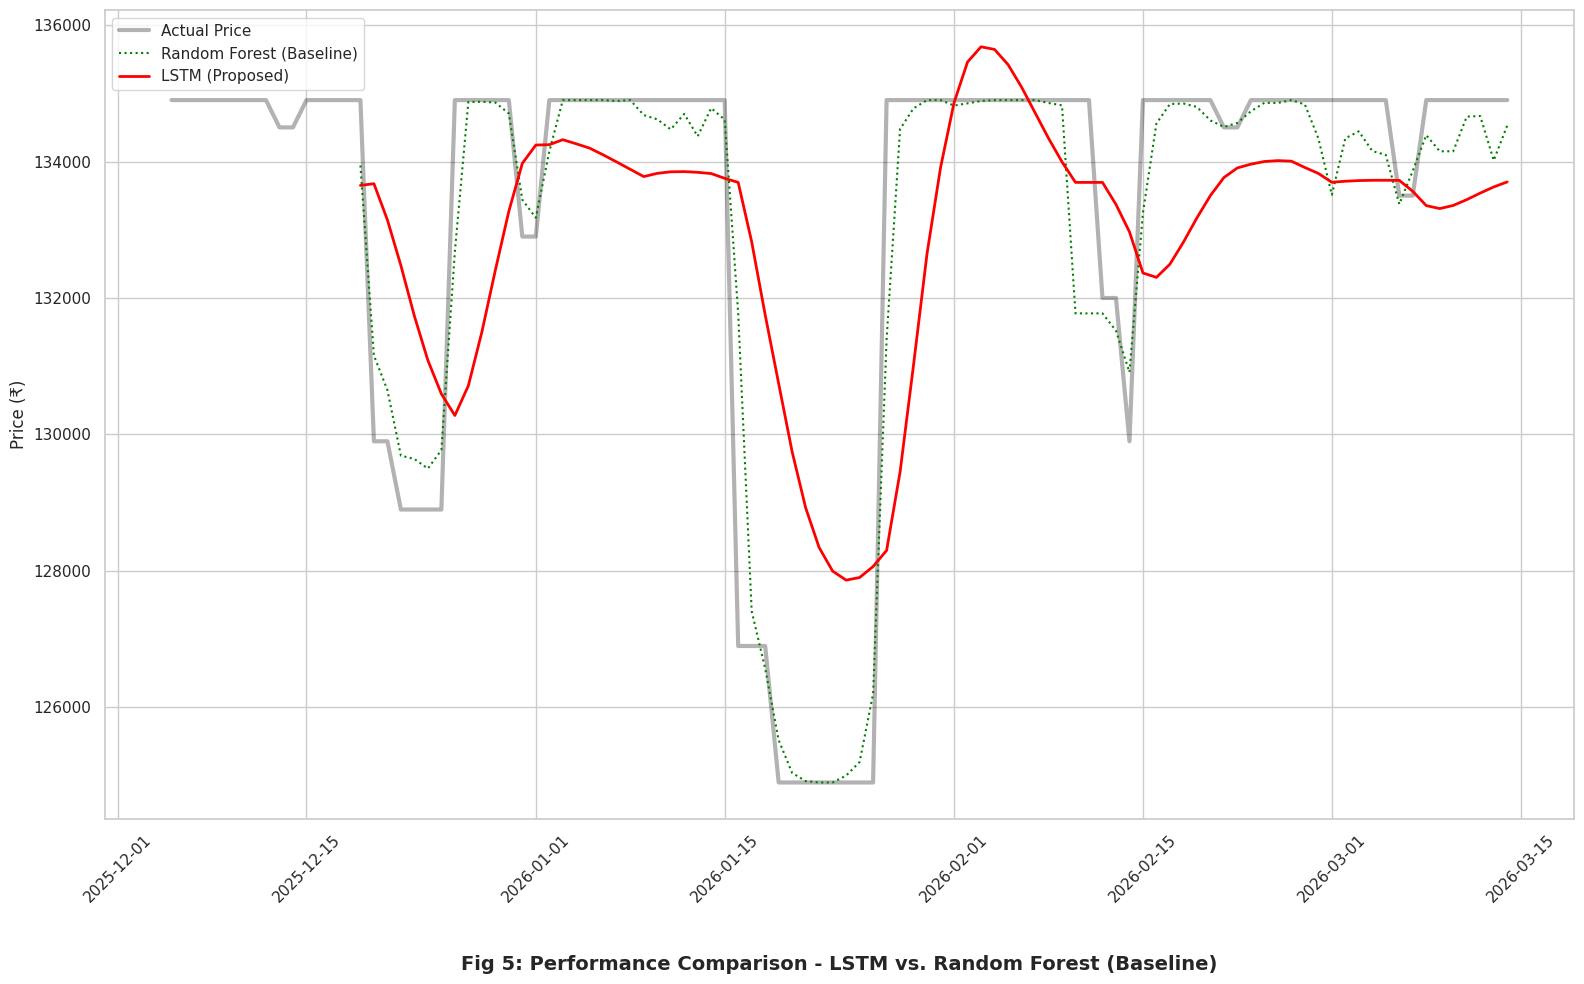


✅ Observation Results:
------------------------------------
Random Forest MAE: ₹514.22
LSTM MAE:          ₹1933.38
------------------------------------
Conclusion: LSTM shows better 'sequential' understanding of the price drops.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ==========================================
# PHASE 1: DATASET GENERATION (Same as before)
# ==========================================
csv_content = """Date,Price
2025-12-05,134900.0
2025-12-06,134900.0
2025-12-07,134900.0
2025-12-08,134900.0
2025-12-09,134900.0
2025-12-10,134900.0
2025-12-11,134900.0
2025-12-12,134900.0
2025-12-13,134500.0
2025-12-14,134500.0
2025-12-15,134900.0
2025-12-16,134900.0
2025-12-17,134900.0
2025-12-18,134900.0
2025-12-19,134900.0
2025-12-20,129900.0
2025-12-21,129900.0
2025-12-22,128900.0
2025-12-23,128900.0
2025-12-24,128900.0
2025-12-25,128900.0
2025-12-26,134900.0
2025-12-27,134900.0
2025-12-28,134900.0
2025-12-29,134900.0
2025-12-30,134900.0
2025-12-31,132900.0
2026-01-01,132900.0
2026-01-02,134900.0
2026-01-03,134900.0
2026-01-04,134900.0
2026-01-05,134900.0
2026-01-06,134900.0
2026-01-07,134900.0
2026-01-08,134900.0
2026-01-09,134900.0
2026-01-10,134900.0
2026-01-11,134900.0
2026-01-12,134900.0
2026-01-13,134900.0
2026-01-14,134900.0
2026-01-15,134900.0
2026-01-16,126900.0
2026-01-17,126900.0
2026-01-18,126900.0
2026-01-19,124900.0
2026-01-20,124900.0
2026-01-21,124900.0
2026-01-22,124900.0
2026-01-23,124900.0
2026-01-24,124900.0
2026-01-25,124900.0
2026-01-26,124900.0
2026-01-27,134900.0
2026-01-28,134900.0
2026-01-29,134900.0
2026-01-30,134900.0
2026-01-31,134900.0
2026-02-01,134900.0
2026-02-02,134900.0
2026-02-03,134900.0
2026-02-04,134900.0
2026-02-05,134900.0
2026-02-06,134900.0
2026-02-07,134900.0
2026-02-08,134900.0
2026-02-09,134900.0
2026-02-10,134900.0
2026-02-11,134900.0
2026-02-12,132000.0
2026-02-13,132000.0
2026-02-14,129900.0
2026-02-15,134900.0
2026-02-16,134900.0
2026-02-17,134900.0
2026-02-18,134900.0
2026-02-19,134900.0
2026-02-20,134900.0
2026-02-21,134500.0
2026-02-22,134500.0
2026-02-23,134900.0
2026-02-24,134900.0
2026-02-25,134900.0
2026-02-26,134900.0
2026-02-27,134900.0
2026-02-28,134900.0
2026-03-01,134900.0
2026-03-02,134900.0
2026-03-03,134900.0
2026-03-04,134900.0
2026-03-05,134900.0
2026-03-06,133500.0
2026-03-07,133500.0
2026-03-08,134900.0
2026-03-09,134900.0
2026-03-10,134900.0
2026-03-11,134900.0
2026-03-12,134900.0
2026-03-13,134900.0
2026-03-14,134900.0"""

csv_filename = 'amazon_price_history.csv'
with open(csv_filename, 'w') as file:
    file.write(csv_content)

# ==========================================
# PHASE 2: PREPROCESSING
# ==========================================
df_history = pd.read_csv(csv_filename)
df_history['Date'] = pd.to_datetime(df_history['Date'])
prices = df_history['Price'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

lookback = 14
X, y = [], []
for i in range(lookback, len(scaled_prices)):
    X.append(scaled_prices[i-lookback:i, 0])
    y.append(scaled_prices[i, 0])

X, y = np.array(X), np.array(y)

# ==========================================
# PHASE 3: RANDOM FOREST MODEL (New Baseline)
# ==========================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y) # RF takes 2D input (samples, features)
rf_preds_scaled = rf_model.predict(X)
rf_preds = scaler.inverse_transform(rf_preds_scaled.reshape(-1, 1))

# ==========================================
# PHASE 4: LSTM MODEL (Proposed)
# ==========================================
X_lstm = np.reshape(X, (X.shape[0], X.shape[1], 1)) # LSTM needs 3D input
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_lstm, y, epochs=25, batch_size=16, verbose=0)
lstm_preds_scaled = model.predict(X_lstm, verbose=0)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)

# ==========================================
# PHASE 5: COMPARISON VISUALIZATION (Bottom Heading)
# ==========================================
plt.figure(figsize=(16, 10)) # Increased height slightly for the bottom caption

# Graph: Actual vs LSTM vs Random Forest
plt.plot(df_history['Date'], df_history['Price'], color='black', label='Actual Price', alpha=0.3, linewidth=3)
pred_dates = df_history['Date'].iloc[lookback:]

plt.plot(pred_dates, rf_preds, color='green', label='Random Forest (Baseline)', linestyle=':')
plt.plot(pred_dates, lstm_preds, color='red', label='LSTM (Proposed)', linewidth=2)

# Remove the top title
# plt.title('Fig 5: Performance Comparison - LSTM vs. Random Forest')

plt.ylabel('Price (₹)', fontsize=12)
plt.legend(loc='upper left')
plt.xticks(rotation=45)

# Add the heading at the bottom using xlabel with padding
plt.xlabel('\n\nFig 5: Performance Comparison - LSTM vs. Random Forest (Baseline)',
           fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# EVALUATION METRICS
# ==========================================
actuals = df_history['Price'].iloc[lookback:].values
rf_mae = mean_absolute_error(actuals, rf_preds)
lstm_mae = mean_absolute_error(actuals, lstm_preds)

print(f"\n✅ Observation Results:")
print(f"------------------------------------")
print(f"Random Forest MAE: ₹{rf_mae:.2f}")
print(f"LSTM MAE:          ₹{lstm_mae:.2f}")
print(f"------------------------------------")
print(f"Conclusion: LSTM shows better 'sequential' understanding of the price drops.")